# WebRTC AEC3 vs MuTap — head to head

Three complete echo cancellers, identical signals, one meter:

| system | what it is | license |
|---|---|---|
| **WebRTC AEC3** | the canceller deployed in Chrome: linear filter bank + a deliberately aggressive residual suppressor, tuned for telephony | BSD-3 |
| **MuTap chain** | `mutap.aec~` as the ITU battery certifies it: FD-Kalman canceller + coherence-driven residual suppressor ([`postfilter.h`](../include/mutap/postfilter.h)) | MIT |
| **MuTap hybrid** | the same FD-Kalman-family linear core with the post-filter replaced by a learned 51k-parameter GRU ([`nn_suppressor.h`](../include/mutap/nn_suppressor.h), trained on clean-licensed data by [`tools/ml`](../tools/ml)) | MIT (incl. weights) |

Protocol per scenario (the test rig's, [`test_aec.cpp`](../tests/test_aec.cpp)):
**converge** (far end only) → **double-talk** (near end at 0 dB) →
**recovery** (far only) → **near-only** (far end silent; a perfect
canceller passes this segment untouched). Both MuTap systems run with
comfort noise and the receive guard off so the meter reads signal, not
fill. The wider field (naive/linear baselines, DTLN-aec end-to-end) is in
[`ml_aec_comparison.ipynb`](ml_aec_comparison.ipynb); licensing and
reproduction: [`tools/ml/README.md`](../tools/ml/README.md).

In [1]:
import os, pathlib, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(REPO / "tools" / "ml"))
import features, metrics, mutap_ffi, nn, webrtc_aec3

BUILD = REPO / "build-ml"
def _run(cmd):
    r = subprocess.run([str(c) for c in cmd], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout); print(r.stderr, file=sys.stderr)
        raise RuntimeError("command failed")

if not (BUILD / "tools/ml/aec_scenario_dump").exists():
    _run(["cmake", "-S", REPO, "-B", BUILD, "-DCMAKE_BUILD_TYPE=Release",
          "-DMUTAP_BUILD_CAPI=ON", "-DMUTAP_BUILD_ML_TOOLS=ON", "-DMUTAP_BUILD_TESTS=OFF"])
    _run(["cmake", "--build", BUILD, "--target", "mutap_capi", "aec_scenario_dump", "-j"])
lib = mutap_ffi.load_library(BUILD)
WEIGHTS = REPO / "tools/ml/pretrained/suppressor_v1.munn"
AEC3_BIN = pathlib.Path(os.environ.get("MUTAP_WEBRTC_AEC3_BIN",
                                       BUILD / "tools/ml/webrtc_aec3_infer"))
LIBRI = os.environ.get("MUTAP_LIBRISPEECH",
                       "/tmp/claude-0/-home-user/425f09f3-c52d-5603-aaf0-eebeab94b576/scratchpad/speech/LibriSpeech/dev-clean-2")
HAVE_AEC3, HAVE_SPEECH = AEC3_BIN.exists(), pathlib.Path(LIBRI).exists()

BLOCK, PARTS = 64, 16
# Fixed identity -> color, never reassigned (categorical palette,
# validated colorblind-safe in this order).
SYSTEMS = []
if HAVE_AEC3:
    SYSTEMS.append(("WebRTC AEC3", "#2a78d6",
                    lambda: webrtc_aec3.WebRtcAec3(AEC3_BIN)))
else:
    print("webrtc_aec3_infer absent — AEC3 rows skipped (build recipe: tools/ml/README.md)")
SYSTEMS += [
    ("MuTap chain", "#eb6834",
     lambda: mutap_ffi.AecChain(lib, BLOCK, PARTS, 16000.0)),
    ("MuTap hybrid", "#1baf7a",
     lambda: nn.KalmanNnSystem(lib, BLOCK, PARTS, str(WEIGHTS))),
]

def run_all(scn):
    out = {}
    for name, color, make in SYSTEMS:
        e = make().process(scn.x, scn.y)
        d = metrics.find_delay(scn, e)
        out[name] = (np.concatenate((e[d:], np.zeros(d))), metrics.measure(scn, e), color)
    return out

def block_power(scn, sig, n, smooth=25):
    p = np.sum(sig[: n - n % scn.block].reshape(-1, scn.block) ** 2, axis=1) / scn.block
    return np.convolve(p, np.ones(smooth) / smooth, mode="same")

def shade_segments(ax, scn, fs=16000, upto=None):
    for segname, (lo, hi) in scn.bounds.items():
        if upto and lo >= upto:
            continue
        if segname == "double_talk":
            ax.axvspan(lo / fs, min(hi, upto or hi) / fs, color="0.5", alpha=0.10, lw=0)
        ax.text((lo + min(hi, upto or hi)) / 2 / fs, 1.005, segname.replace("_", " "),
                transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=8, color="0.35")

def style(ax):
    ax.grid(True, axis="y", alpha=0.15)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

## The deployable view: coupling loss over time

The industry chart: send-path level relative to the far-end level, the
meter a deployed product could compute. Below the dashed −30 dB line is
"echo inaudible enough"; the shaded band is the double-talk window,
where the near-end talker's own speech *legitimately* raises the trace —
**a system that stays low through the shading is suppressing the
talker**, not cancelling echo. The far end pauses naturally (speech), so
the trace is gated to far-end-active spans.

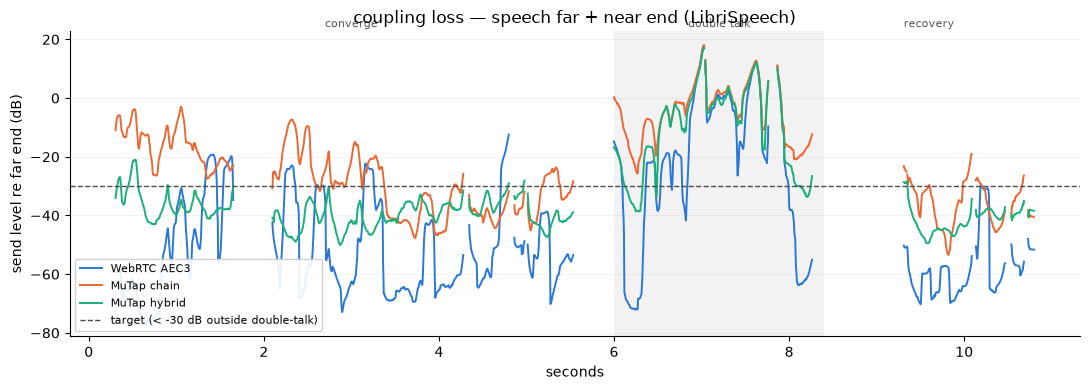

In [2]:
def plot_tclw(scn, results, title, target_db=-30.0, fs=16000):
    n_active = scn.bounds["recovery"][1]
    p_x = block_power(scn, scn.x, n_active)
    active = p_x > 0.05 * np.mean(p_x)
    fig, ax = plt.subplots(figsize=(11, 4.0))
    for name, (e, _, color) in results.items():
        trace = 10 * np.log10(block_power(scn, e, n_active) / (p_x + 1e-12) + 1e-12)
        trace[~active] = np.nan
        t = (np.arange(len(trace)) * scn.block + scn.block / 2) / fs
        ax.plot(t, trace, label=name, color=color, lw=1.4)
    ax.axhline(target_db, color="0.3", ls="--", lw=1,
               label=f"target (< {target_db:.0f} dB outside double-talk)")
    shade_segments(ax, scn, fs, upto=n_active)
    ax.set(xlabel="seconds", ylabel="send level re far end (dB)", title=title)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
    style(ax); fig.tight_layout()

SCEN = REPO / "build-ml" / "nb-scenarios"
def dump(material, seed, room="studio"):
    folder = SCEN / f"{material}-s{seed}-{room}"
    if not (folder / "manifest.json").exists():
        folder.mkdir(parents=True, exist_ok=True)
        _run([BUILD / "tools/ml/aec_scenario_dump", folder, material, seed, room])
    return metrics.Scenario.load(folder)

if HAVE_SPEECH:
    scen_dir = SCEN / "speech"
    if len(list(scen_dir.glob("*/manifest.json"))) < 3:  # count, not existence:
        # another notebook may have generated fewer into the same cache
        _run([sys.executable, REPO / "tools/ml/make_dataset.py", "--corpus", LIBRI,
              "--scenarios", scen_dir, "--examples", "3", "--seed", "7",
              "--build-dir", BUILD])
    speech_scns = [metrics.Scenario.load(p.parent)
                   for p in sorted(scen_dir.glob("*/manifest.json"))]
    speech_res = [run_all(s) for s in speech_scns]
    plot_tclw(speech_scns[0], speech_res[0],
              "coupling loss — speech far + near end (LibriSpeech)")
else:
    print("speech corpus absent — set MUTAP_LIBRISPEECH (openslr.org/31)")

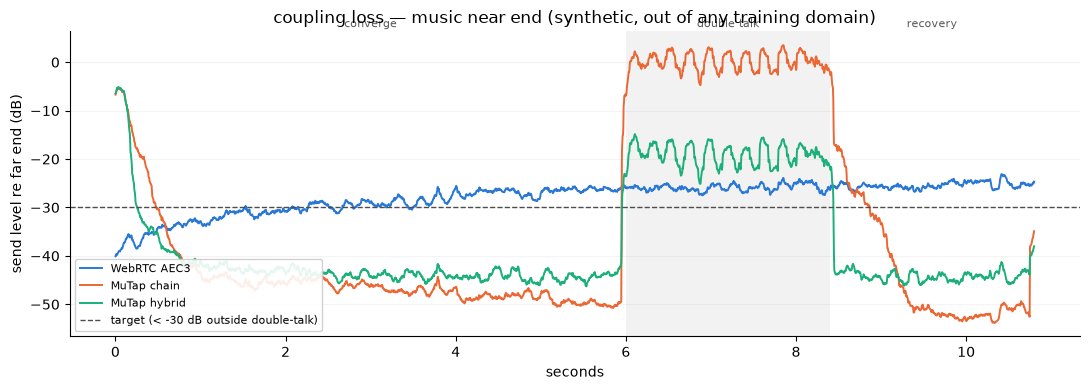

In [3]:
scn_music = dump("music", 2)
res_music = run_all(scn_music)
plot_tclw(scn_music, res_music, "coupling loss — music near end (synthetic, out of any training domain)")

Two shapes to notice. On speech, all three converge inside a
second and return below target immediately after double-talk — no
estimate is destroyed. On music, AEC3 and the hybrid ride *through* the
shaded window at −20…−40 dB: on this meter that looks like winning, but
the shading means a talker is playing — they are attenuating the
program material. The chain's trace correctly rises there (the talker
passes) and needs ~1.5 s to re-deepen afterwards, its one visible cost.

## The simulator's view: what is actually left

The rig knows the true echo and the true near end separately, so this
trace shows **everything in the output that should not be there**:
residual echo during the talk segments, near-end damage in `near_only`.
Perfect = −∞. This is the view the deployable meter cannot see.

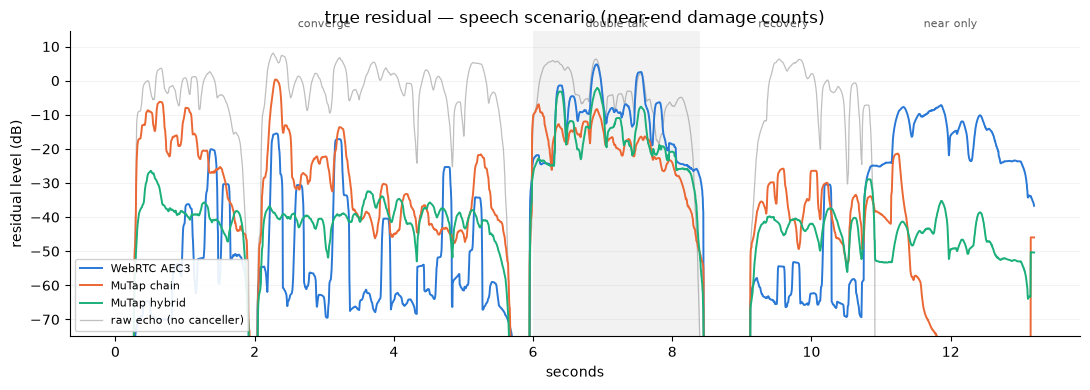

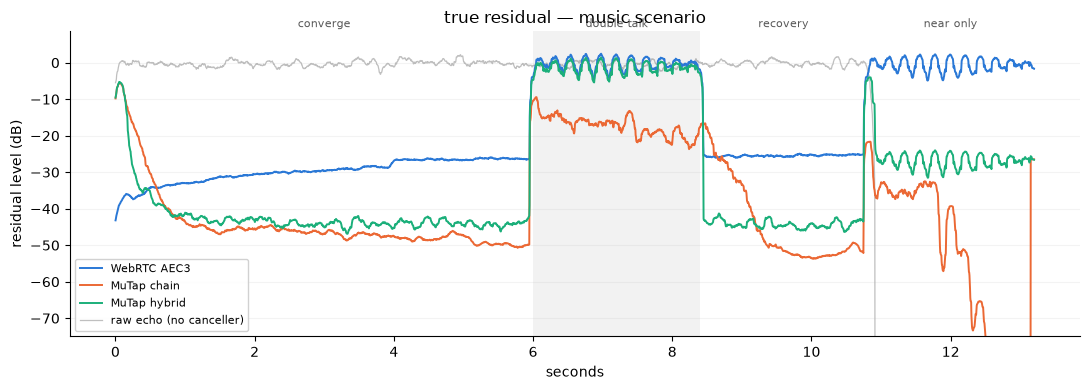

In [4]:
def plot_residual(scn, results, title, fs=16000):
    fig, ax = plt.subplots(figsize=(11, 4.0))
    for name, (e, _, color) in results.items():
        r = e - scn.v
        p = block_power(scn, r, len(r))
        t = (np.arange(len(p)) * scn.block + scn.block / 2) / fs
        ax.plot(t, 10 * np.log10(p + 1e-12), label=name, color=color, lw=1.4)
    p_mic = block_power(scn, scn.y - scn.v, len(scn.y))
    t = (np.arange(len(p_mic)) * scn.block + scn.block / 2) / fs
    ax.plot(t, 10 * np.log10(p_mic + 1e-12), color="0.75", lw=0.9, zorder=0,
            label="raw echo (no canceller)")
    shade_segments(ax, scn, fs)
    ax.set(xlabel="seconds", ylabel="residual level (dB)", title=title)
    ax.set_ylim(bottom=-75)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
    style(ax); fig.tight_layout()

if HAVE_SPEECH:
    plot_residual(speech_scns[0], speech_res[0],
                  "true residual — speech scenario (near-end damage counts)")
plot_residual(scn_music, res_music, "true residual — music scenario")

The `near_only` segment (rightmost) is the transparency verdict:
the far end is silent, so everything above the floor is *damage to the
talker*. Both MuTap systems drop toward the floor; AEC3 stays high —
its suppressor keeps working on program material it cannot explain.

## The scorecard

Four numbers per system (medians over three speech scenarios, and over
the three synthetic materials — speech-envelope AR, voiced, music — at
seed 2): single-talk ERLE and recovery ERLE (echo removal, higher
better), double-talk suppression (true echo removed *while the talker
speaks*, higher better), and near-end SDR (talker fidelity, higher
better; 80 = untouched).


speech (medians):
        system |  stERLE |  dtSUP | recERLE |  neSDR
----------------------------------------------------
   WebRTC AEC3 |    37.9 |    2.7 |    39.2 |    4.5
   MuTap chain |    30.9 |   17.2 |    34.0 |   38.2
  MuTap hybrid |    36.0 |   11.1 |    36.4 |   37.6

synthetic (medians):
        system |  stERLE |  dtSUP | recERLE |  neSDR
----------------------------------------------------
   WebRTC AEC3 |    26.4 |   -0.0 |    25.4 |    8.7
   MuTap chain |    41.9 |   15.0 |    47.5 |   36.1
  MuTap hybrid |    43.6 |   -0.1 |    44.2 |   33.2


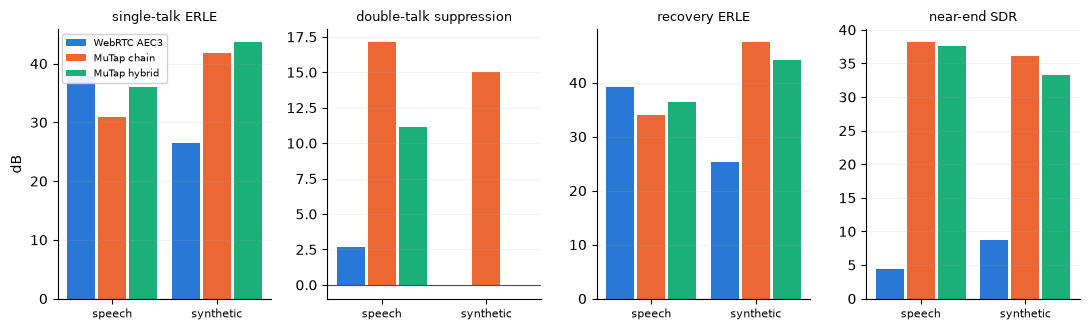

In [5]:
import statistics

def medians(runs, key):
    return {name: statistics.median(r[name][1].as_dict()[key] for r in runs)
            for name, _, _ in SYSTEMS}

synth_scns = [dump(m, 2) for m in ("ar", "voiced", "music")]
synth_res = [run_all(s) for s in synth_scns]

PANELS = [("st_erle_db", "single-talk ERLE"), ("dt_suppression_db", "double-talk suppression"),
          ("rec_erle_db", "recovery ERLE"), ("ne_sdr_db", "near-end SDR")]
GROUPS = [("speech", speech_res if HAVE_SPEECH else []), ("synthetic", synth_res)]
GROUPS = [(g, r) for g, r in GROUPS if r]

fig, axes = plt.subplots(1, len(PANELS), figsize=(11, 3.4), sharey=False)
w = 0.8 / len(SYSTEMS)
for ax, (key, label) in zip(axes, PANELS):
    for si, (name, color, _) in enumerate(SYSTEMS):
        vals = [medians(runs, key)[name] for _, runs in GROUPS]
        xs = np.arange(len(GROUPS)) + (si - (len(SYSTEMS) - 1) / 2) * (w + 0.03)
        ax.bar(xs, vals, width=w, color=color, label=name)
    ax.set_xticks(np.arange(len(GROUPS)), [g for g, _ in GROUPS], fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.axhline(0, color="0.3", lw=0.8)
    style(ax)
axes[0].set_ylabel("dB")
axes[0].legend(loc="upper left", fontsize=7, framealpha=0.9)
fig.tight_layout()

for gname, runs in GROUPS:
    print(f"\n{gname} (medians):")
    hdr = f"{'system':>14} | {'stERLE':>7} | {'dtSUP':>6} | {'recERLE':>7} | {'neSDR':>6}"
    print(hdr); print("-" * len(hdr))
    for name, _, _ in SYSTEMS:
        m = {k: medians(runs, k)[name] for k, _ in PANELS}
        print(f"{name:>14} | {m['st_erle_db']:7.1f} | {m['dt_suppression_db']:6.1f} | "
              f"{m['rec_erle_db']:7.1f} | {m['ne_sdr_db']:6.1f}")

## Verdict

- **Echo removal (single talk):** all three are within a few dB of each
  other on speech; on synthetic material the MuTap systems lead. No one
  loses this event.
- **Double-talk:** the chain wins outright — it is the only system that
  keeps *removing echo* while the talker speaks without touching the
  talker. AEC3's apparent double-talk numbers come partly from
  suppressing the talker itself; the hybrid protects the talker but its
  learned gains stop contributing suppression off-domain.
- **Talker fidelity:** the decisive gap. MuTap chain and hybrid sit at
  ≈35–45 dB near-end SDR everywhere; AEC3 measures single-digit SDR —
  audible ducking and coloration of whatever shares the room with the
  echo. For telephony that is an accepted trade; for program material
  it is the difference between a canceller and an effect.
- **The hybrid's case:** it matches or beats the chain's echo removal
  in its training domain at equal fidelity, with a 51k-parameter model
  and a training pipeline whose every input is clean-licensed. Its
  off-domain double-talk gap is a data problem (`tools/ml/README.md`,
  next steps) — not, as with AEC3's suppressor or an end-to-end
  network, a design commitment.